# Section 1: Environment Setup, Paths & Data Loading

In [5]:
import os
import joblib
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# 2. Define path to your project folder in Google Drive
# Update 'Telecom_Cell_Outage_Project' to your exact Drive folder name
# PROJECT_DIR should be a directory, not a file.
PROJECT_DIR = '/content/drive/MyDrive'

# DATA_PATH should now directly point to your dataset file.
DATA_PATH = os.path.join(PROJECT_DIR, 'mobi_data2_final_engineered.csv')

# MODELS_DIR will now correctly be '/content/drive/MyDrive/models'
MODELS_DIR = os.path.join(PROJECT_DIR, 'models')

os.makedirs(MODELS_DIR, exist_ok=True)

# 3. Load Featured Dataset
print(f"Loading dataset from: {DATA_PATH}")
if DATA_PATH.endswith('.parquet'):
    df = pd.read_parquet(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH)

print(f"Dataset successfully loaded. Shape: {df.shape}")

Loading dataset from: /content/drive/MyDrive/mobi_data2_final_engineered.csv
Dataset successfully loaded. Shape: (999999, 23)


# Section 2: Stratified Split & Multi-Model Training Pipeline


In [14]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd

# 1. Separate Features (X) and Target (y)
metadata_to_drop = [
    'location_information', 'additional_information',
    'enodeb_id', 'gnodeb_id', 'mo_name', 'alarm_id'
]

X = df.drop(columns=[c for c in metadata_to_drop if c in df.columns], errors='ignore')
if 'target' in X.columns:
    y = X['target']
    X = X.drop(columns=['target'])
else:
    raise KeyError("Target column 'target' not found in dataset!")

# Preserve categorical types
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category')

# 2. Stratified 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Compute class balance scale factor (~1:9 imbalance ratio)
scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)
print(f"Training Features: {X_train.shape} | Testing Features: {X_test.shape}")
print(f"Calculated Imbalance Ratio (scale_pos_weight): {scale_pos:.4f}\n")

# 3. Define Model Suite
models = {
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos, enable_categorical=True,
        tree_method='hist', random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos, random_state=42, n_jobs=-1, verbose=-1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight='balanced',
        random_state=42, n_jobs=-1
    )
}

# 4. Train Models & Measure Validation Benchmarks
trained_models = {}
validation_summary = []

print("--- Starting Multi-Model Comparison Training ---")
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    y_probs = model.predict_proba(X_test)[:, 1]

    roc = roc_auc_score(y_test, y_probs)
    pr_auc = average_precision_score(y_test, y_probs)

    trained_models[name] = model
    validation_summary.append({
        'Model': name,
        'ROC-AUC': round(roc, 4),
        'PR-AUC': round(pr_auc, 4)
    })
    print(f"  └─ {name} | ROC-AUC: {roc:.4f} | PR-AUC: {pr_auc:.4f}")

# 5. Display Leaderboard Summary
summary_df = pd.DataFrame(validation_summary).sort_values(by='PR-AUC', ascending=False)
print("\n" + "="*45)
print("     MULTI-MODEL TRAINING LEADERBOARD      ")
print("="*45)
print(summary_df.to_string(index=False))

# 6. Save Model Artifacts locally in your repo's /models directory
joblib.dump(trained_models, os.path.join(MODELS_DIR, 'all_trained_models.joblib'))
joblib.dump({'X_test': X_test, 'y_test': y_test}, os.path.join(MODELS_DIR, 'test_data_split.joblib'))

print(f"\nAll artifacts successfully saved to local directory: {MODELS_DIR}/")

Training Features: (799999, 22) | Testing Features: (200000, 22)
Calculated Imbalance Ratio (scale_pos_weight): 8.3985

--- Starting Multi-Model Comparison Training ---
Training XGBoost...
  └─ XGBoost | ROC-AUC: 0.9791 | PR-AUC: 0.8930
Training LightGBM...
  └─ LightGBM | ROC-AUC: 0.9794 | PR-AUC: 0.8943
Training RandomForest...
  └─ RandomForest | ROC-AUC: 0.9756 | PR-AUC: 0.8795

     MULTI-MODEL TRAINING LEADERBOARD      
       Model  ROC-AUC  PR-AUC
    LightGBM   0.9794  0.8943
     XGBoost   0.9791  0.8930
RandomForest   0.9756  0.8795

All artifacts successfully saved to local directory: /content/drive/MyDrive/models/


#Model Evaluation

--- Computing Multi-Model Performance Metrics ---

             OFFICIAL MULTI-MODEL PERFORMANCE SCORECARD            
       Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
    LightGBM    0.9153     0.5625  0.9165    0.6972   0.9794  0.8943
     XGBoost    0.9152     0.5623  0.9141    0.6963   0.9791  0.8930
RandomForest    0.9264     0.6053  0.8854    0.7190   0.9756  0.8795

--- Training Loss Tracking Models ---


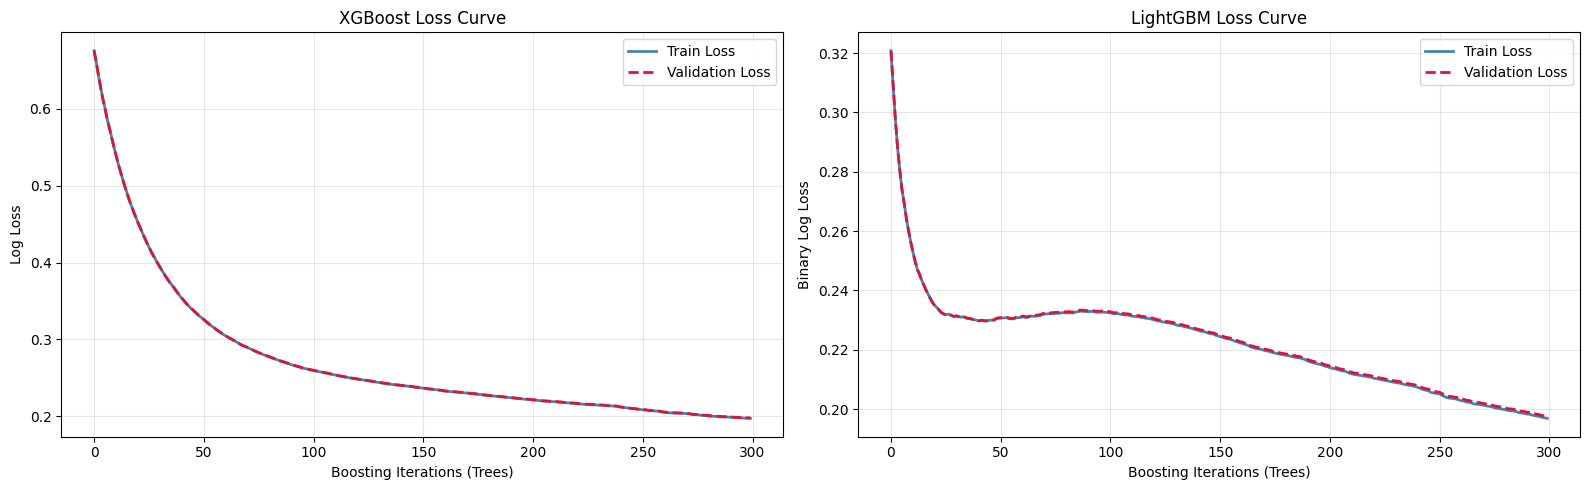

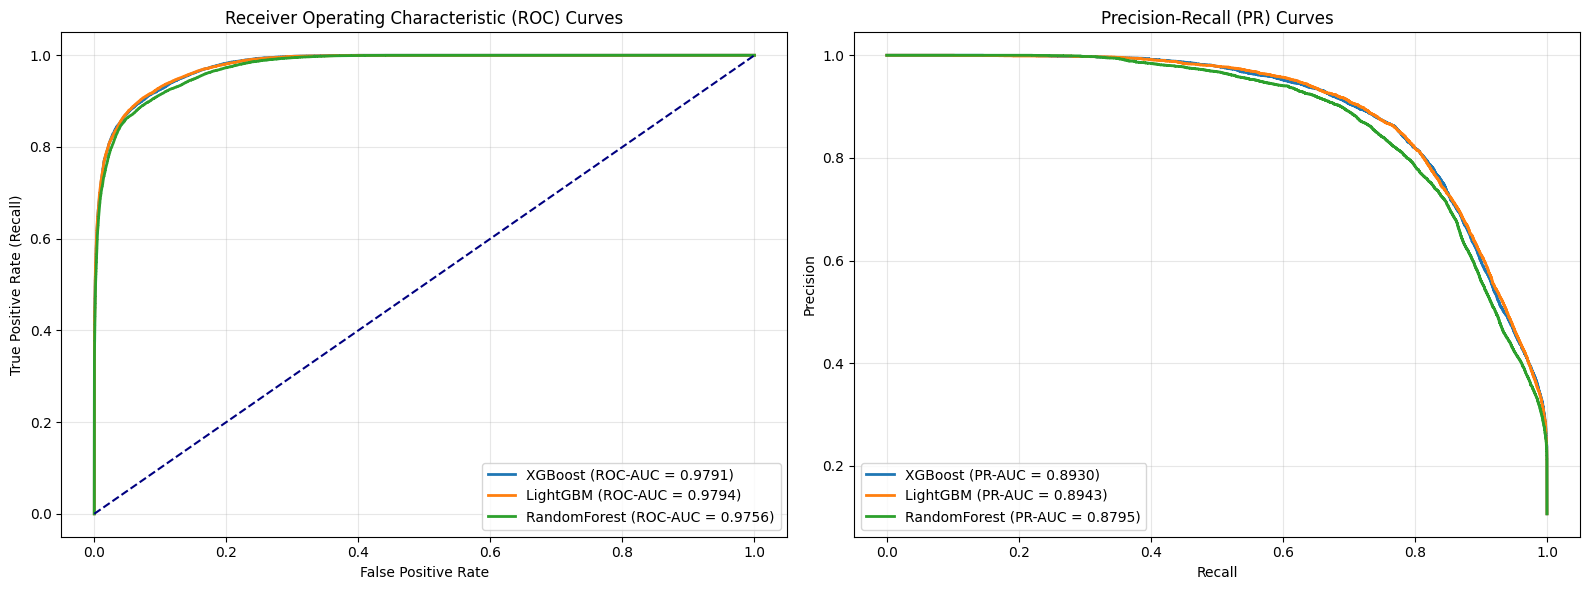


--- Decision Threshold Tuning (LightGBM) ---
Optimal Probability Threshold for Max F1: 0.7981
-------------------------------------------------------
  Accuracy @ Optimal Threshold:  0.9615
  Precision @ Optimal Threshold: 0.8431
  Recall @ Optimal Threshold:    0.7843
  F1-Score @ Optimal Threshold:  0.8127
  ROC-AUC Score:                0.9794
-------------------------------------------------------

Classification Report at Optimal Threshold:
              precision    recall  f1-score   support

           0     0.9745    0.9826    0.9786    178720
           1     0.8431    0.7843    0.8127     21280

    accuracy                         0.9615    200000
   macro avg     0.9088    0.8835    0.8956    200000
weighted avg     0.9605    0.9615    0.9609    200000



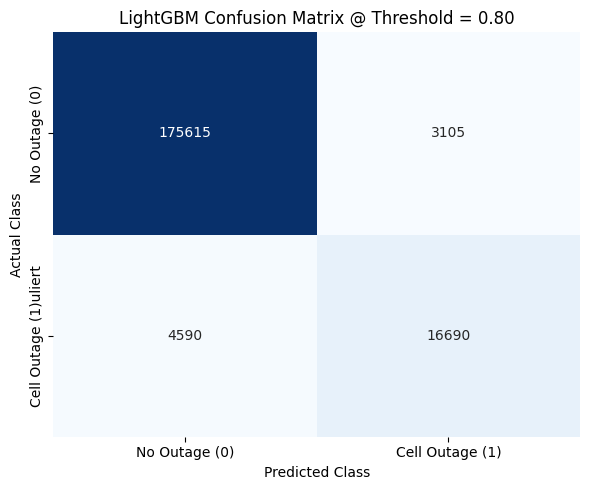


Champion model exported to /content/drive/MyDrive/models/champion_model.joblib


In [21]:
# =========================================================
# Section 3: Comprehensive Multi-Model Metrics Scorecard
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)

# 1. Evaluate default (0.5 threshold) metrics across all models
model_scorecard = []

print("--- Computing Multi-Model Performance Metrics ---")
for name, model in trained_models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs >= 0.5).astype(int)

    model_scorecard.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_probs), 4),
        'PR-AUC': round(average_precision_score(y_test, y_probs), 4)
    })

scorecard_df = pd.DataFrame(model_scorecard).sort_values(by='PR-AUC', ascending=False)

print("\n" + "="*70)
print("             OFFICIAL MULTI-MODEL PERFORMANCE SCORECARD            ")
print("="*70)
print(scorecard_df.to_string(index=False))

# =========================================================
# Section 4: Loss Curves (Training vs Validation Log-Loss)
# =========================================================

print("\n--- Training Loss Tracking Models ---")

# Re-fit XGBoost with evaluation history enabled
eval_xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.03, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos, enable_categorical=True,
    tree_method='hist', random_state=42, n_jobs=-1,
    eval_metric='logloss'
)
eval_xgb.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

# Re-fit LightGBM with evaluation history enabled
eval_lgb = LGBMClassifier(
    n_estimators=300, learning_rate=0.03, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos, random_state=42, n_jobs=-1, verbose=-1,
    eval_metric='binary_logloss'
)
eval_lgb.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)])

# Plot Loss Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot XGBoost Loss Curve
xgb_hist = eval_xgb.evals_result()
axes[0].plot(xgb_hist['validation_0']['logloss'], label='Train Loss', color='steelblue', lw=2)
axes[0].plot(xgb_hist['validation_1']['logloss'], label='Validation Loss', color='crimson', lw=2, linestyle='--')
axes[0].set_xlabel('Boosting Iterations (Trees)')
axes[0].set_ylabel('Log Loss')
axes[0].set_title('XGBoost Loss Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot LightGBM Loss Curve
lgb_hist = eval_lgb.evals_result_
axes[1].plot(lgb_hist['training']['binary_logloss'], label='Train Loss', color='steelblue', lw=2)
axes[1].plot(lgb_hist['valid_1']['binary_logloss'], label='Validation Loss', color='crimson', lw=2, linestyle='--')
axes[1].set_xlabel('Boosting Iterations (Trees)')
axes[1].set_ylabel('Binary Log Loss')
axes[1].set_title('LightGBM Loss Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# Section 5: ROC and Precision-Recall Curves Plotting
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, model in trained_models.items():
    y_probs = model.predict_proba(X_test)[:, 1]

    # ROC Curves
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (ROC-AUC = {roc_auc_score(y_test, y_probs):.4f})')

    # PR Curves
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    axes[1].plot(recall, precision, lw=2, label=f'{name} (PR-AUC = {average_precision_score(y_test, y_probs):.4f})')

axes[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curves')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (PR) Curves')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# Section 6: Threshold Optimization & Confusion Matrix
# =========================================================

champion_name = scorecard_df.iloc[0]['Model']
champion_model = trained_models[champion_name]

print(f"\n--- Decision Threshold Tuning ({champion_name}) ---")
y_probs_champ = champion_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_champ)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

# Optimized Predictions
y_pred_optimal = (y_probs_champ >= optimal_threshold).astype(int)

opt_acc = accuracy_score(y_test, y_pred_optimal)
opt_prec = precisions[best_idx]
opt_rec = recalls[best_idx]
opt_f1 = f1_scores[best_idx]
opt_roc_auc = roc_auc_score(y_test, y_probs_champ)

print(f"Optimal Probability Threshold for Max F1: {optimal_threshold:.4f}")
print("-" * 55)
print(f"  Accuracy @ Optimal Threshold:  {opt_acc:.4f}")
print(f"  Precision @ Optimal Threshold: {opt_prec:.4f}")
print(f"  Recall @ Optimal Threshold:    {opt_rec:.4f}")
print(f"  F1-Score @ Optimal Threshold:  {opt_f1:.4f}")
print(f"  ROC-AUC Score:                {opt_roc_auc:.4f}")
print("-" * 55)

print("\nClassification Report at Optimal Threshold:")
print(classification_report(y_test, y_pred_optimal, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Outage (0)', 'Cell Outage (1)'],
            yticklabels=['No Outage (0)', 'Cell Outage (1)uliert']) # Label was 'Cell Outage (1)' so should be fine
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title(f'{champion_name} Confusion Matrix @ Threshold = {optimal_threshold:.2f}')
plt.tight_layout()
plt.show()

# Export Champion Model Artifacts
joblib.dump({
    'model_name': champion_name,
    'model': champion_model,
    'threshold': optimal_threshold,
    'features': list(X_train.columns)
}, os.path.join(MODELS_DIR, 'champion_model.joblib'))

print(f"\nChampion model exported to {MODELS_DIR}/champion_model.joblib")
